## Case Study: Understanding Passenger Age Distribution

#### A cruise company wants to better understand the age profile of its passengers so it can improve onboard services and entertainment.
The analytics team has been asked to answer the following questions:
- Which age group has the highest number of passengers?
- Is the passenger age distribution concentrated around a particular age?
- What is the probability that a randomly selected passenger is between 20 and 40 years old?
- What is the probability density at age 30, and what does it tell us about passenger concentration around this age?
- What is the probability that a randomly selected passenger belongs to each passenger class (1st, 2nd, or 3rd Class)?

# 

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats 
import numpy as np

In [34]:
data = pd.read_csv('titanic.csv')

In [35]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [36]:
data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [37]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [38]:
data.isnull().mean()*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [39]:
data = data[['PassengerId','Survived','Pclass','Sex','Age','Fare']]

In [40]:
data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Sex             object
Age            float64
Fare           float64
dtype: object

In [41]:
data['Age'] = data.groupby('Sex')['Age'].transform(lambda x: x.fillna(x.mean()))

In [42]:
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
Fare           0
dtype: int64

In [43]:
data.duplicated().sum()

np.int64(0)

In [44]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,891.0,29.736034,13.014897,0.42,22.0000,30.0000,35.0,80.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [45]:
data.min()

PassengerId         1
Survived            0
Pclass              1
Sex            female
Age              0.42
Fare              0.0
dtype: object

In [46]:
data.max()

PassengerId         891
Survived              1
Pclass                3
Sex                male
Age                80.0
Fare           512.3292
dtype: object

In [47]:
 np.ceil(data['Age']).min()

1.0

In [49]:
data['Age'] =  np.ceil(data['Age'])

In [50]:
data.min()

PassengerId         1
Survived            0
Pclass              1
Sex            female
Age               1.0
Fare              0.0
dtype: object

# 

####  Histogram of Passenger Age

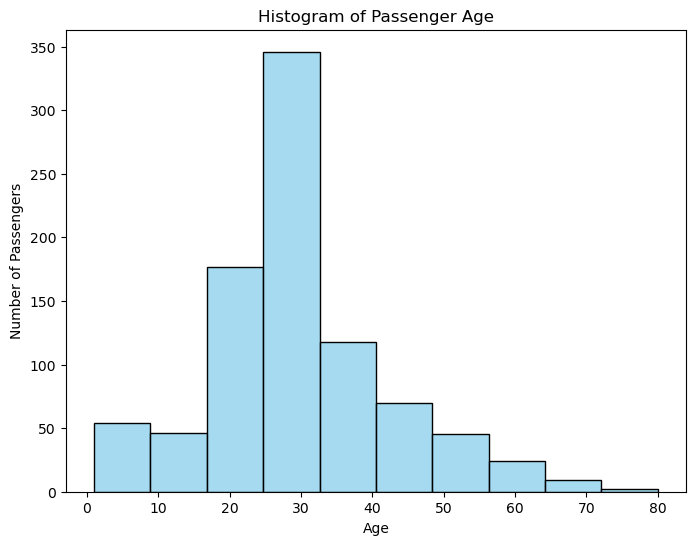

In [62]:
plt.figure(figsize=(8,6))
sns.histplot(data=data,x="Age",bins=10,color="skyblue",edgecolor="black")
plt.title("Histogram of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

- The highest number of passengers is around 20 to 38 years.
- Very few passengers are children or old people.
- Most passenger ages are in the middle range.

# 

#### KDE plot 

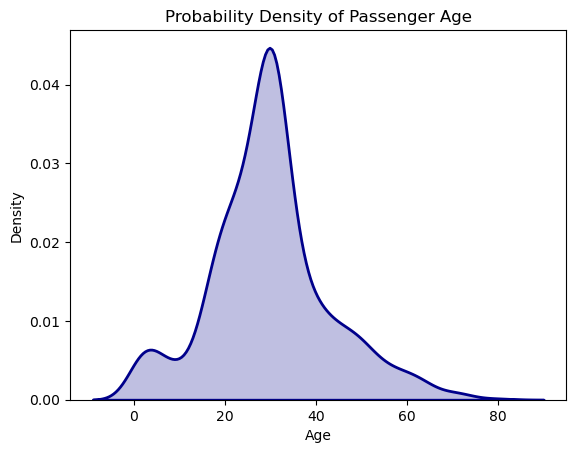

In [120]:
sns.kdeplot(data=data,x='Age',fill=True,linewidth=2,color='darkblue')
plt.title("Probability Density of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

- The highest peak is around 20 to 38 years.
- Thses means most passengers are 20–38 years old.
- Very young and older passengers have lower density.  
The KDE curve shows the age distribution clearly.

# 

### Probability Calculation

#### Q.  What is the probability that a randomly selected passenger is between 20 and 40 years old?

In [92]:
mean_age = data['Age'].mean()

In [140]:
std_age = data["Age"].std()

###### Cumulative probability up to lower age

In [96]:
lower_age = 20

In [101]:
cdf_lower = stats.norm.cdf(lower_age, loc=mean_age, scale=std_age)

In [103]:
print(cdf_lower)

0.25014719723194956


###### Cumulative probability up to upper age

In [106]:
upper_age = 40

In [108]:
cdf_upper = stats.norm.cdf(upper_age, loc=mean_age, scale=std_age)

In [111]:
print(cdf_upper)

0.7588997586292031


##### between lower and upper age 


In [113]:
probability = cdf_upper - cdf_lower

In [116]:
probability

np.float64(0.5087525613972536)

In [119]:
print('Mean Age : ',mean_age)
print('Std Age : ',std_age)
print('-'*50)
print('Probability:', probability)
print(f'Percentage: {probability*100:.2f}%')

Mean Age :  29.791245791245792
Std Age :  14.526497332334044
--------------------------------------------------
Probability: 0.5087525613972536
Percentage: 50.88%


##### probability is about 0.50 (50%). This means around 50% of passengers are between 20 and 40 years old.

# 

#### Q. What is the probability density at age 30, and what does it tell us about passenger concentration around this age?

In [124]:
age =  30

In [132]:
stats.norm.pdf(age, loc=mean_age, scale=std_age)

np.float64(0.027460239030673454)

In [135]:
pdf_value = stats.norm.pdf(age, loc=mean_age, scale=std_age)

In [136]:
print(f'Mean Age: {mean_age:.2f}')
print(f'Standard Deviation: {std_age:.2f}')
print(f'Probability Density at Age {age}: {pdf_value:.4f}')

Mean Age: 29.79
Standard Deviation: 14.53
Probability Density at Age 30: 0.0275


 - The PDF value at 30 years is 0.0275.
- This means passenger ages are highly concentrated around 30 years.

# 

#### Q. What is the probability that a randomly selected passenger belongs to each passenger class (1st, 2nd, or 3rd Class)?

In [141]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'Fare'], dtype='object')

In [143]:
data['Pclass'].unique()

array([3, 1, 2])

In [148]:
data['Pclass'].value_counts(normalize=True).sort_index()

Pclass
1    0.242424
2    0.206510
3    0.551066
Name: proportion, dtype: float64

In [149]:
pmf = data['Pclass'].value_counts(normalize=True).sort_index()

In [152]:
print('Percentage of Passengers in Each Class:')
for pclass, probability in pmf.items():
    print(f'Class {pclass}: {probability:.2%}')

Percentage of Passengers in Each Class:
Class 1: 24.24%
Class 2: 20.65%
Class 3: 55.11%


- 3rd Class has the highest probability.
- so most passengers traveled in 3rd Class.
- 1st and 2nd Class have fewer passengers than 3rd Class.